<a href="https://www.kaggle.com/code/avikdas567/global-renewable-energy-shift-analysis-2000-2025?scriptVersionId=321048355" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Global Renewable Energy Shift Analysis 2000-2025

## Tracking the Global Electricity Transition

This notebook analyzes how electricity generation changed across 309 countries and regions between 2000 and 2025 using data from Our World in Data and Ember.

The dataset includes electricity generation and electricity share metrics across solar, wind, hydro, nuclear, coal, gas, oil, and other energy sources. The analysis focuses on long-term transition patterns, renewable adoption trends, fossil fuel dependence, and large-scale electricity system changes.

The notebook combines exploratory analysis, visualization, machine learning, deep learning, clustering, and forecasting techniques to study how countries are progressing through the global energy transition.

### Topics Covered

- Dataset structure and quality checks
- Missing value analysis
- Global renewable electricity trends
- Fossil fuel dependency patterns
- Solar, wind, hydro, and nuclear growth
- Country-level transition comparisons
- Coal dependency across major economies
- Correlation analysis
- Country clustering and segmentation
- Machine learning regression models
- Deep learning prediction models
- Renewable energy forecasting
- Energy transition scorecards

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

from xgboost import XGBRegressor

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42


## Load Dataset


In [2]:
DATA_PATH = "/kaggle/input/datasets/elvisbui/renewable-energy-share-by-country-2000-2025/renewable_energy_share_2000_2025.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (7636, 33)


,country,year,iso_code,population,gdp,primary_energy_consumption,electricity_generation,electricity_demand,renewables_share_energy,renewables_share_elec,...,solar_share_elec,wind_share_elec,hydro_share_elec,nuclear_share_elec,coal_share_elec,gas_share_elec,energy_per_capita,renewables_energy_per_capita,fossil_energy_per_capita,renewables_cons_change_twh
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,378.76,378.76,NaN,19.334,...,0.0,0.0,13.314,0.0,20.073,43.368,NaN,NaN,NaN,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,405.09,405.09,NaN,19.055,...,0.0,0.0,13.412,0.0,21.294,47.004,NaN,NaN,NaN,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,433.19,433.19,NaN,17.667,...,0.0,0.0,12.304,0.0,21.568,48.228,NaN,NaN,NaN,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,458.30,458.30,NaN,16.668,...,0.0,0.0,11.610,0.0,22.258,49.424,NaN,NaN,NaN,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,496.61,496.61,NaN,15.696,...,0.0,0.0,10.670,0.0,23.159,49.165,NaN,NaN,NaN,NaN


## Analysis

The dataset is relatively compact but information-dense. With more than two decades of country-level electricity data, it captures both mature and emerging renewable transitions.

A dataset of this size is large enough for meaningful machine learning experiments while still being manageable for exploratory analysis and visualization.


## Column Overview


In [3]:
pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.values,
    "missing_values": df.isna().sum().values,
    "missing_pct": (df.isna().mean() * 100).round(2).values
}).sort_values("missing_pct", ascending=False)

,column,dtype,missing_values,missing_pct
31,fossil_energy_per_capita,float64,5386,70.53
30,renewables_energy_per_capita,float64,5386,70.53
12,low_carbon_share_energy,float64,4861,63.66
8,renewables_share_energy,float64,4861,63.66
10,fossil_share_energy,float64,4861,63.66
32,renewables_cons_change_twh,float64,4861,63.66
4,gdp,float64,3836,50.24
2,iso_code,object,2087,27.33
29,energy_per_capita,float64,2068,27.08
3,population,float64,1790,23.44



## Basic Dataset Information


In [4]:
print("Countries / Regions:", df["country"].nunique())
print("Year Range:", df["year"].min(), "-", df["year"].max())
print("Total Missing Values:", df.isna().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

Countries / Regions: 309
Year Range: 2000 - 2025
Total Missing Values: 69817
Duplicate Rows: 0


## Analysis

The dataset covers a broad mix of sovereign countries, territories, and aggregated regions. This wide geographic coverage makes it possible to compare very different electricity systems under a common framework.

The presence of both advanced and developing economies creates strong variation across renewable adoption patterns, fossil dependence, and electricity generation scale.


## Numerical Feature Summary


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,7636.0,2.012002e+03,7.261077e+00,2.000000e+03,2.006000e+03,2.012000e+03,2.018000e+03,2.025000e+03
population,5846.0,1.276241e+08,6.298665e+08,1.776000e+03,9.186292e+05,6.882693e+06,2.784505e+07,8.231613e+09
gdp,3800.0,8.569239e+11,5.998881e+12,3.128536e+08,2.367882e+10,7.808994e+10,3.546080e+11,1.301126e+14
primary_energy_consumption,6582.0,5.018384e+03,1.777536e+04,0.000000e+00,9.128250e+00,8.344650e+01,8.214745e+02,1.767371e+05
electricity_generation,6353.0,8.179377e+02,2.844888e+03,0.000000e+00,1.120000e+00,1.415000e+01,1.199600e+02,3.177235e+04
electricity_demand,6028.0,6.721037e+02,2.647544e+03,0.000000e+00,1.320000e+00,1.128500e+01,9.055250e+01,3.177235e+04
renewables_share_energy,2775.0,1.287070e+01,1.425243e+01,0.000000e+00,2.987500e+00,7.945000e+00,1.801250e+01,8.612600e+01
renewables_share_elec,6327.0,3.102112e+01,3.113353e+01,0.000000e+00,3.590500e+00,2.000000e+01,5.280200e+01,1.000000e+02
fossil_share_energy,2775.0,8.337673e+01,1.572651e+01,1.387400e+01,7.643600e+01,8.668300e+01,9.566400e+01,1.000000e+02
fossil_share_elec,6227.0,6.484129e+01,3.200857e+01,0.000000e+00,4.118550e+01,7.140300e+01,9.572050e+01,1.000000e+02



## Missing Value Analysis


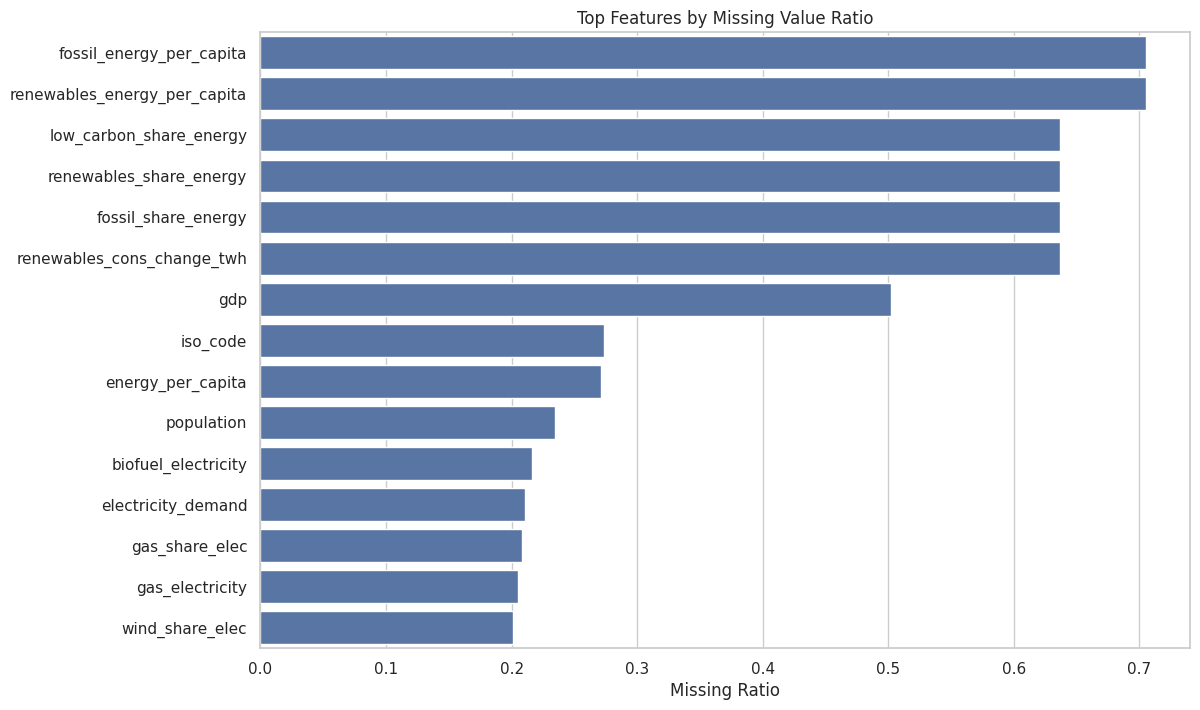

In [6]:
missing_df = (
    df.isna()
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

missing_df.columns = ["feature", "missing_ratio"]

plt.figure(figsize=(12, 8))
sns.barplot(
    data=missing_df.head(15),
    x="missing_ratio",
    y="feature"
)

plt.title("Top Features by Missing Value Ratio")
plt.xlabel("Missing Ratio")
plt.ylabel("")
plt.show()

## Analysis

Missing values are concentrated in newer technologies and recently reported years. Solar and wind adoption expanded unevenly across countries, so earlier years naturally contain gaps for many regions.

The 2025 data is partially reported, which is expected because several countries have not yet published complete electricity statistics for the year.


## Global Renewable Electricity Share Over Time


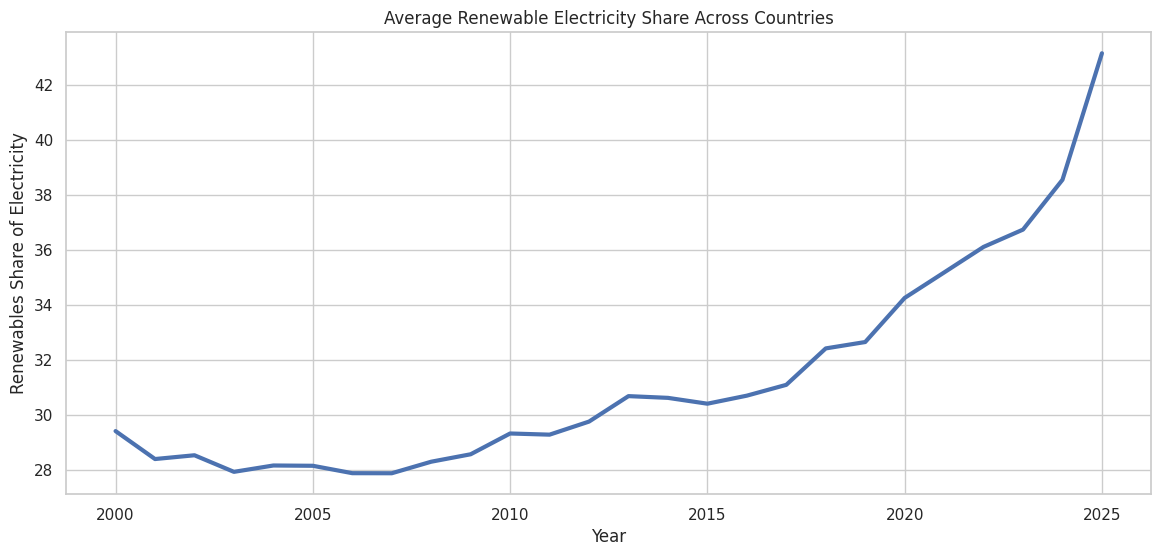

In [7]:
global_trend = (
    df.groupby("year")["renewables_share_elec"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(14, 6))
plt.plot(
    global_trend["year"],
    global_trend["renewables_share_elec"],
    linewidth=3
)

plt.title("Average Renewable Electricity Share Across Countries")
plt.xlabel("Year")
plt.ylabel("Renewables Share of Electricity")
plt.show()

## Analysis

The long-term trend clearly points upward. Renewable electricity adoption accelerated gradually during the early 2000s and then strengthened significantly after 2015.

The steepening slope during the later years reflects large-scale solar and wind deployment, especially across China, Europe, and parts of Latin America.


## Fossil Share Trend


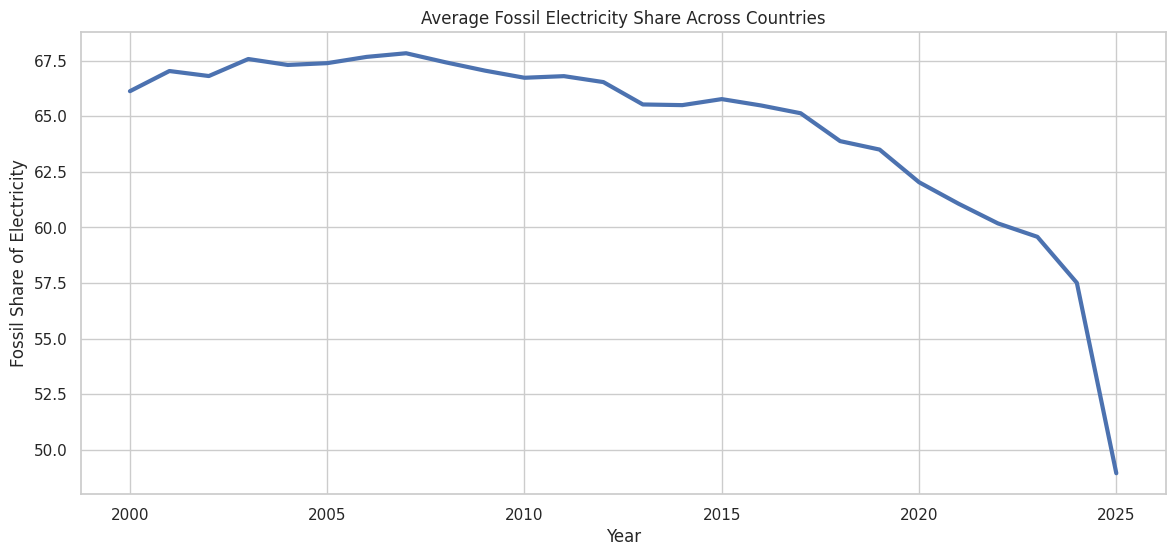

In [8]:
fossil_trend = (
    df.groupby("year")["fossil_share_elec"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(14, 6))
plt.plot(
    fossil_trend["year"],
    fossil_trend["fossil_share_elec"],
    linewidth=3
)

plt.title("Average Fossil Electricity Share Across Countries")
plt.xlabel("Year")
plt.ylabel("Fossil Share of Electricity")
plt.show()

## Analysis

Fossil fuel dependence remains structurally high across many electricity systems, but the overall direction is declining.

The decline is slower than the renewable growth trend because electricity demand itself continues to expand globally. In many countries, renewable additions are supplementing demand growth rather than fully replacing fossil generation.


## Solar and Wind Expansion


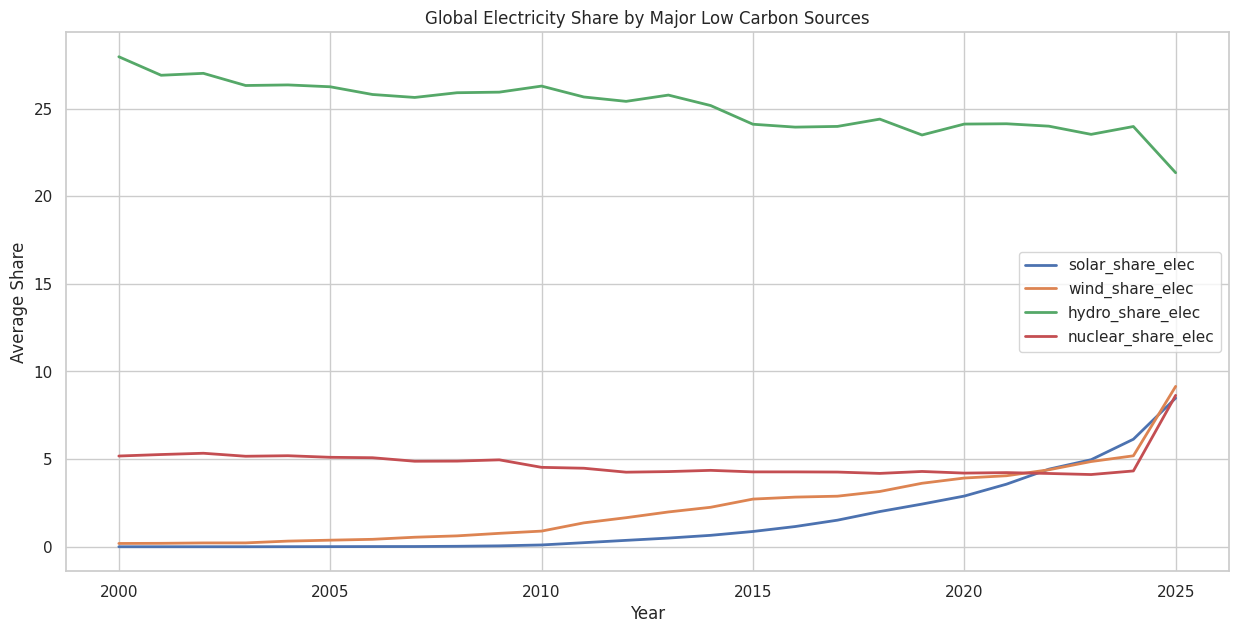

In [9]:
source_trend = (
    df.groupby("year")[[
        "solar_share_elec",
        "wind_share_elec",
        "hydro_share_elec",
        "nuclear_share_elec"
    ]]
    .mean()
)

plt.figure(figsize=(15, 7))

for col in source_trend.columns:
    plt.plot(
        source_trend.index,
        source_trend[col],
        linewidth=2,
        label=col
    )

plt.legend()
plt.title("Global Electricity Share by Major Low Carbon Sources")
plt.xlabel("Year")
plt.ylabel("Average Share")
plt.show()

## Analysis

Hydro remains the dominant renewable source globally, but its growth is comparatively stable.

Solar and wind show the strongest acceleration over time. Solar, in particular, exhibits exponential-like growth after the mid-2010s, reflecting falling panel costs, supportive policy frameworks, and rapid manufacturing expansion.

Nuclear remains relatively flat compared to variable renewables.


## Countries With Highest Renewable Share in Latest Year


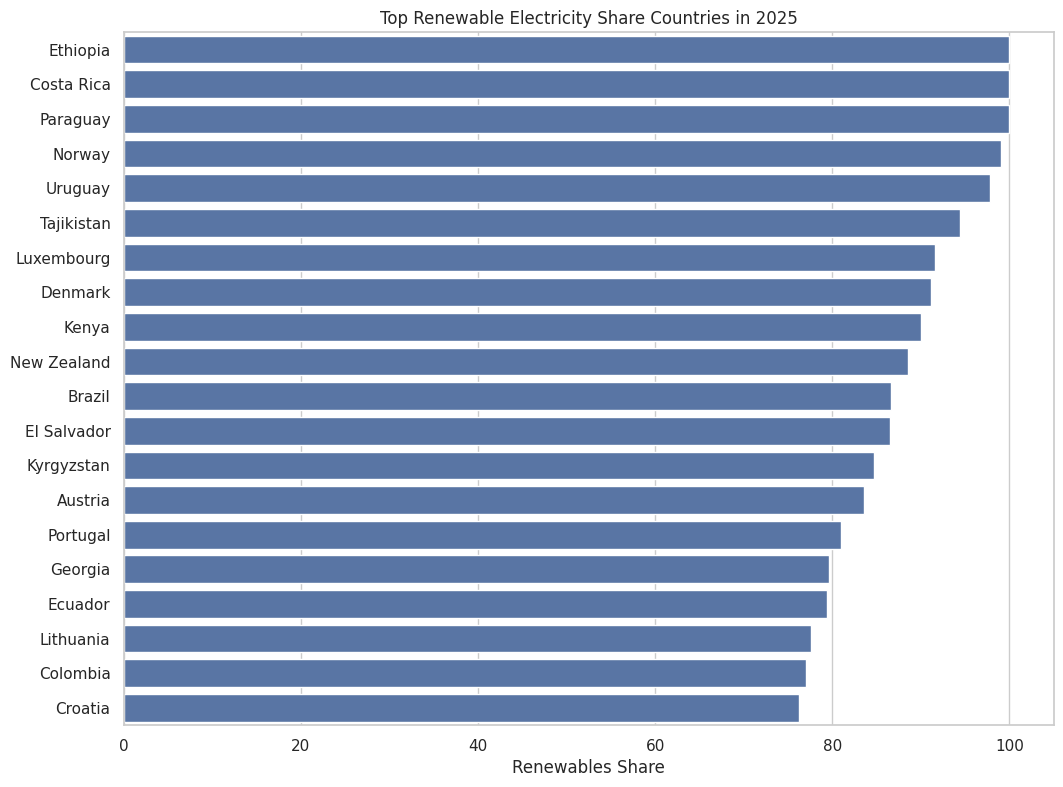

,country,renewables_share_elec
2136,Ethiopia,100.000
1538,Costa Rica,100.000
5686,Paraguay,100.000
4926,Norway,98.999
7319,Uruguay,97.822
6787,Tajikistan,94.366
3765,Luxembourg,91.558
1742,Denmark,91.171
3383,Kenya,90.028
4534,New Zealand,88.533


In [10]:
latest_year = df["year"].max()

latest_df = (
    df[df["year"] == latest_year]
    .dropna(subset=["renewables_share_elec"])
)

top_renewable = (
    latest_df.sort_values(
        "renewables_share_elec",
        ascending=False
    )
    .head(20)
)

plt.figure(figsize=(12, 9))

sns.barplot(
    data=top_renewable,
    x="renewables_share_elec",
    y="country"
)

plt.title(f"Top Renewable Electricity Share Countries in {latest_year}")
plt.xlabel("Renewables Share")
plt.ylabel("")
plt.show()

top_renewable[["country", "renewables_share_elec"]]

## Analysis

Most countries at the top of the renewable ranking are hydro-dominated systems with smaller populations and favorable geography.

Large economies rarely achieve near-100% renewable electricity because industrial demand, grid stability requirements, and legacy fossil infrastructure create additional constraints.


## Largest Renewable Growth Since 2000


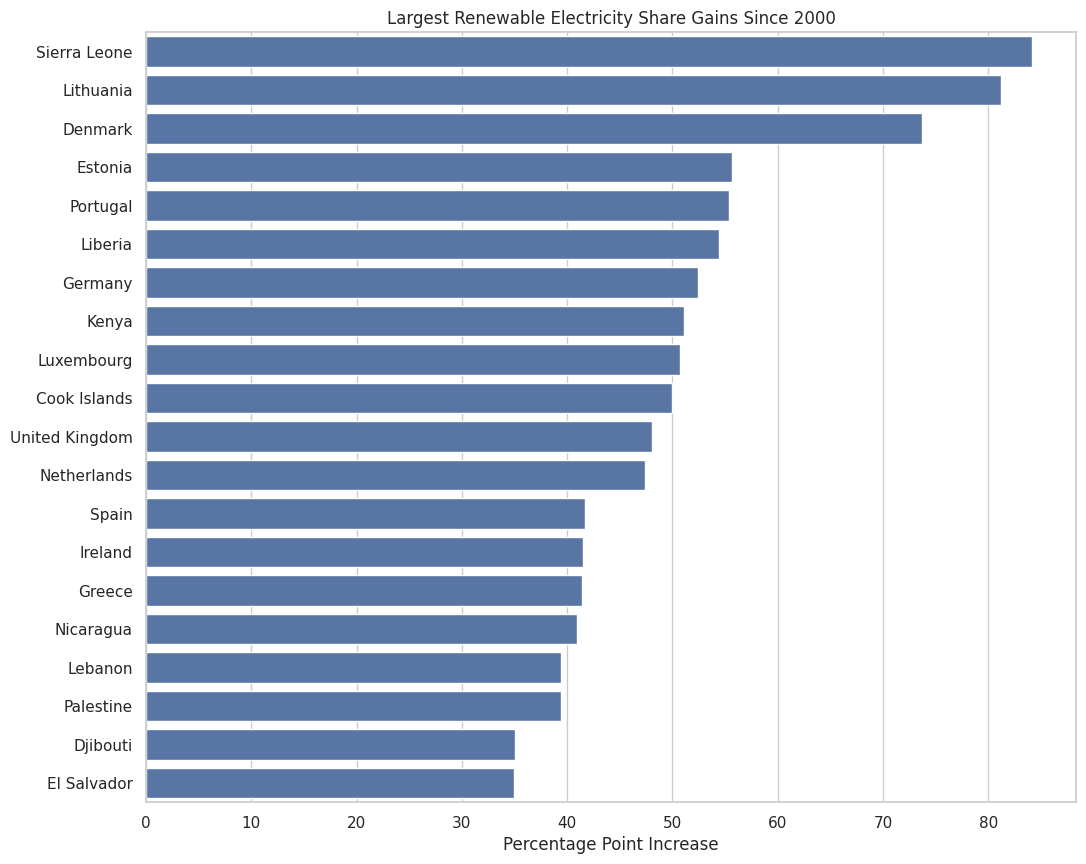

,country,renewables_2000,renewables_2024,growth
208,Sierra Leone,11.111,95.238,84.127
124,Lithuania,3.055,84.303,81.248
58,Denmark,15.537,89.190,73.653
68,Estonia,0.118,55.751,55.633
193,Portugal,29.785,85.191,55.406
122,Liberia,0.000,54.386,54.386
84,Germany,6.224,58.642,52.418
112,Kenya,40.371,91.478,51.107
127,Luxembourg,40.000,90.728,50.728
49,Cook Islands,0.000,50.000,50.000


In [11]:
base_2000 = (
    df[df["year"] == 2000][
        ["country", "renewables_share_elec"]
    ]
    .rename(columns={
        "renewables_share_elec": "renewables_2000"
    })
)

latest_year_df = (
    df[df["year"] == 2024][
        ["country", "renewables_share_elec"]
    ]
    .rename(columns={
        "renewables_share_elec": "renewables_2024"
    })
)

growth_df = base_2000.merge(
    latest_year_df,
    on="country",
    how="inner"
)

growth_df["growth"] = (
    growth_df["renewables_2024"] -
    growth_df["renewables_2000"]
)

growth_df = growth_df.sort_values(
    "growth",
    ascending=False
)

plt.figure(figsize=(12, 10))

sns.barplot(
    data=growth_df.head(20),
    x="growth",
    y="country"
)

plt.title("Largest Renewable Electricity Share Gains Since 2000")
plt.xlabel("Percentage Point Increase")
plt.ylabel("")
plt.show()

growth_df.head(20)

## Analysis

The countries with the largest gains are not necessarily those with the highest absolute renewable share today.

This distinction matters because transition momentum often reveals more than current ranking alone. Several countries started from heavily fossil-based systems and achieved major structural shifts over the last two decades.


## Coal Dependency Comparison

This section compares coal dependence trajectories across major economies.


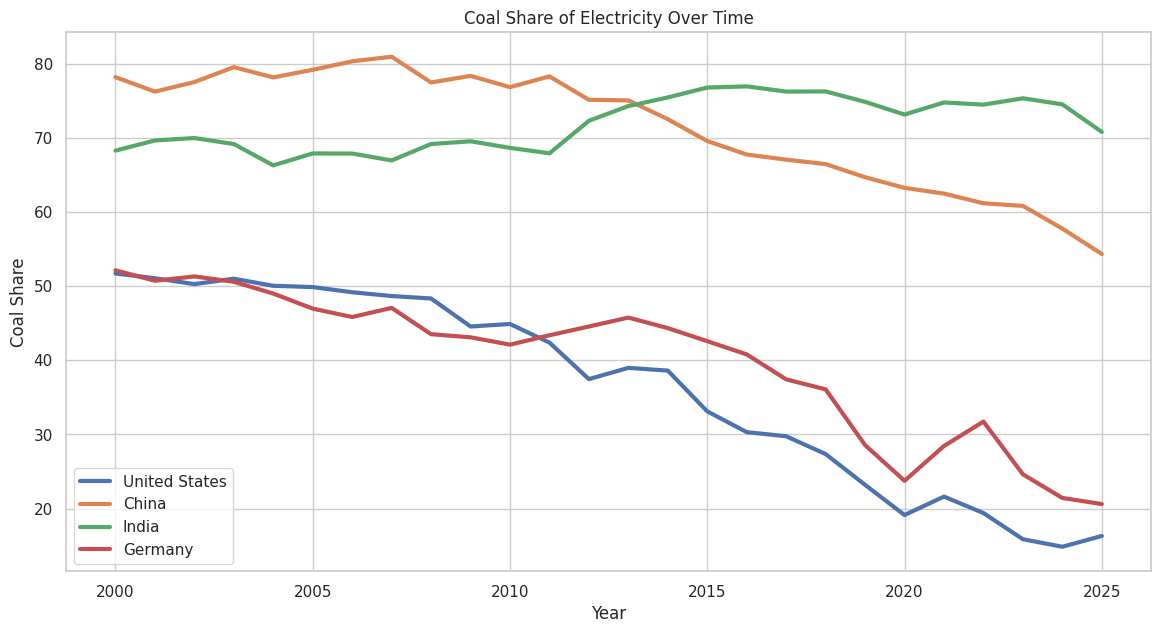

In [12]:
focus_countries = [
    "United States",
    "China",
    "India",
    "Germany"
]

coal_df = (
    df[df["country"].isin(focus_countries)]
)

plt.figure(figsize=(14, 7))

for country in focus_countries:
    temp = coal_df[coal_df["country"] == country]

    plt.plot(
        temp["year"],
        temp["coal_share_elec"],
        linewidth=3,
        label=country
    )

plt.legend()
plt.title("Coal Share of Electricity Over Time")
plt.xlabel("Year")
plt.ylabel("Coal Share")
plt.show()

## Analysis

The coal trajectories differ sharply across major economies.

Germany shows a clear structural decline in coal usage over time, while China and India continue to rely heavily on coal due to industrial demand and rapidly growing electricity consumption.

The United States exhibits a meaningful reduction driven by natural gas substitution and renewable expansion.


## Correlation Matrix


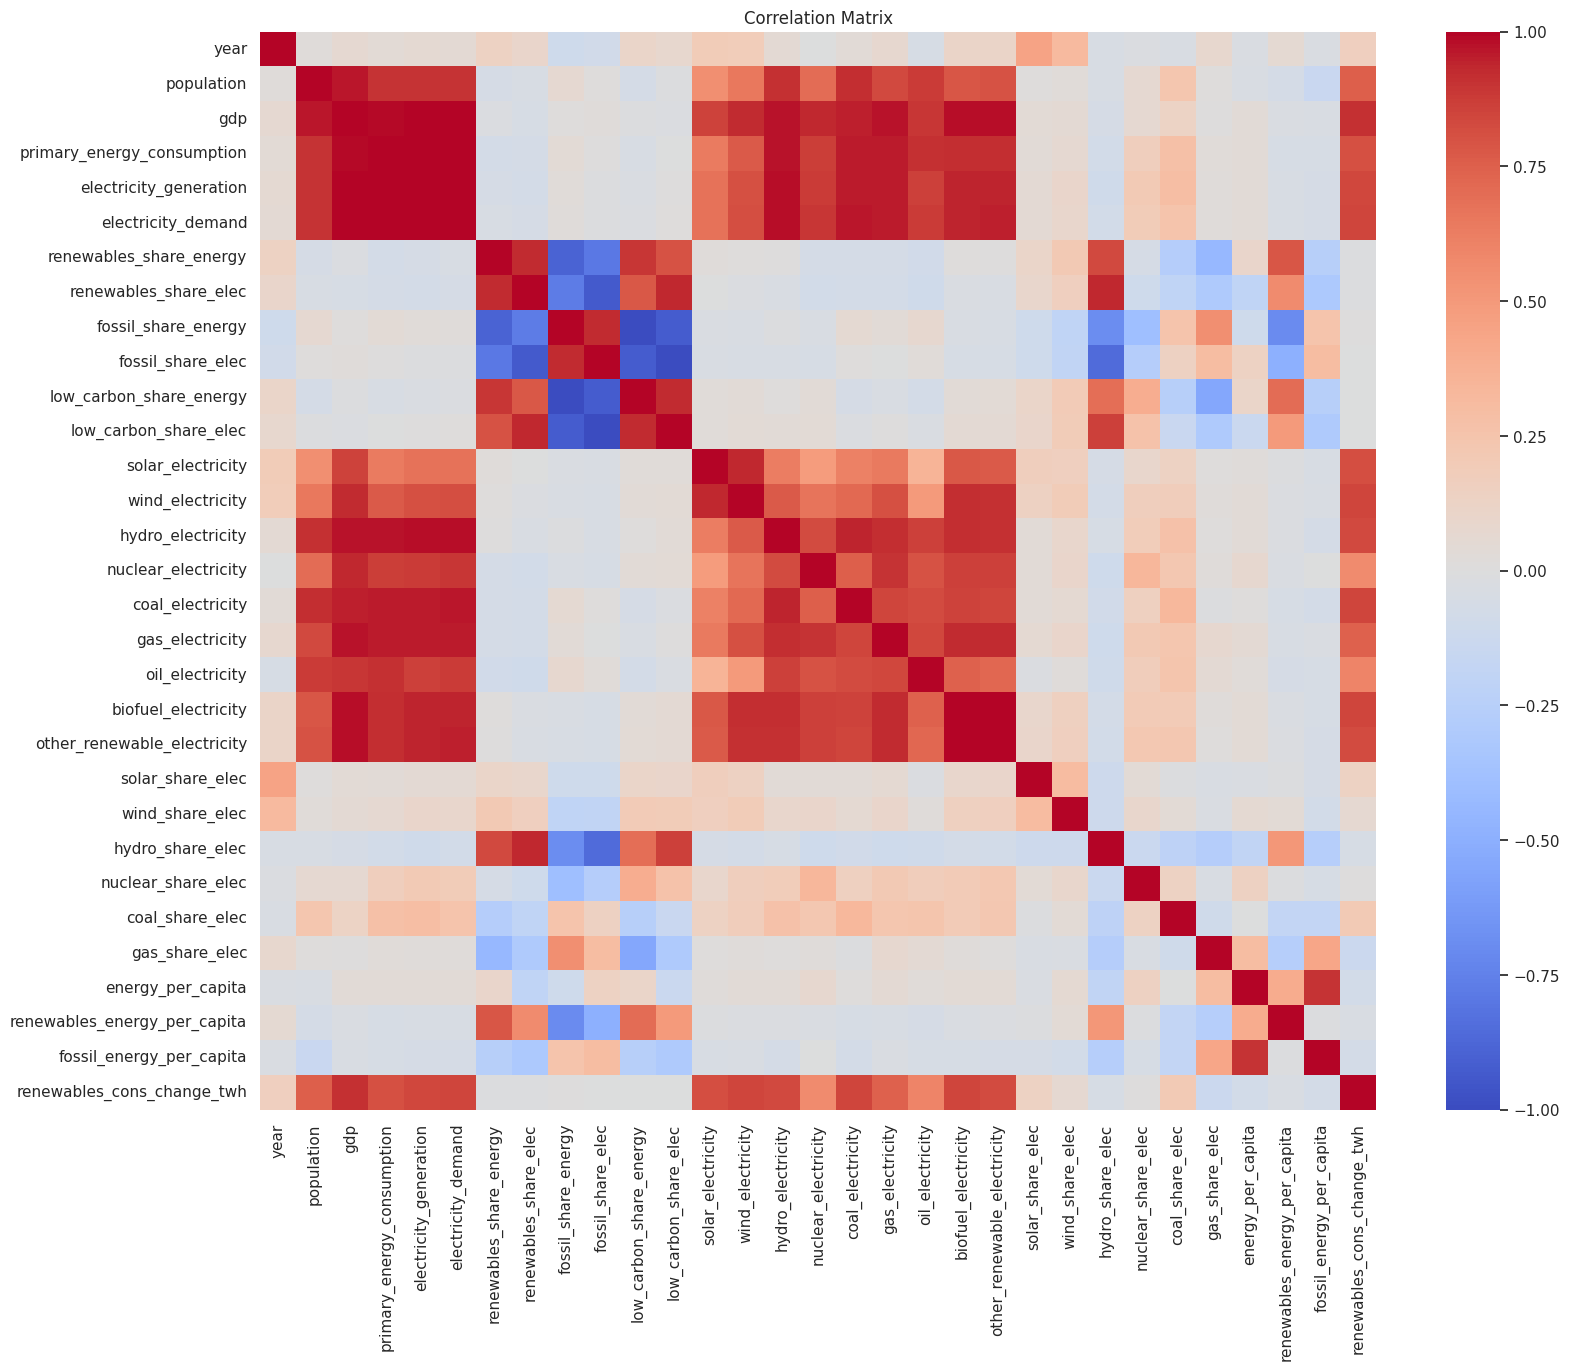

In [13]:
numeric_cols = df.select_dtypes(include=np.number).columns

corr_matrix = (
    df[numeric_cols]
    .corr()
)

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

## Analysis

Strong negative relationships appear between renewable and fossil electricity shares, which is expected because electricity mix components compete within a finite generation system.

Hydro-heavy systems often behave differently from solar- and wind-driven systems, which creates interesting sub-structures inside the correlation matrix.


## Renewable vs Fossil Electricity Relationship


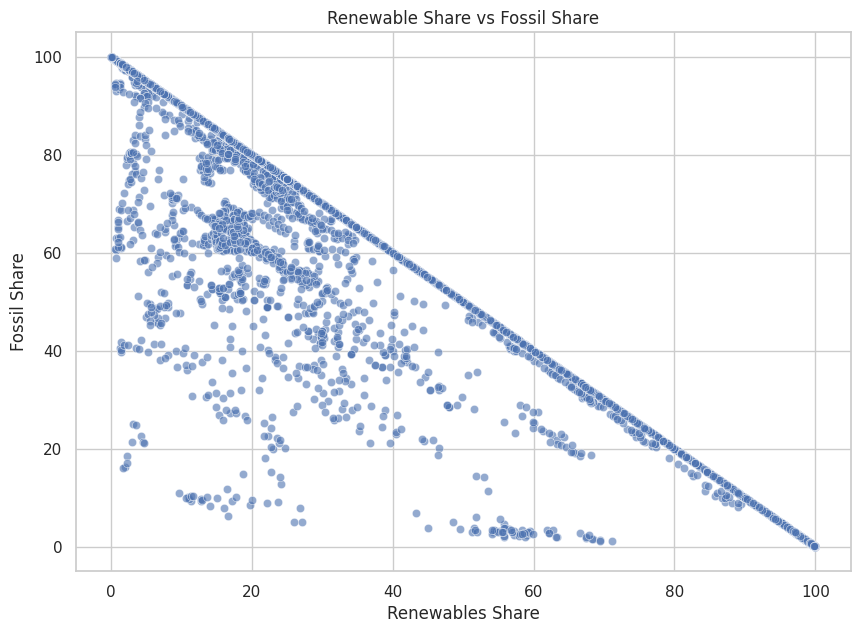

In [14]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="renewables_share_elec",
    y="fossil_share_elec",
    alpha=0.6
)

plt.title("Renewable Share vs Fossil Share")
plt.xlabel("Renewables Share")
plt.ylabel("Fossil Share")
plt.show()

## Analysis

The inverse relationship between renewable and fossil electricity shares is visually clear.

However, the spread around the trend line also shows that countries can maintain mixed systems where renewables grow without immediately eliminating fossil generation.


## Per Capita Energy Consumption Distribution


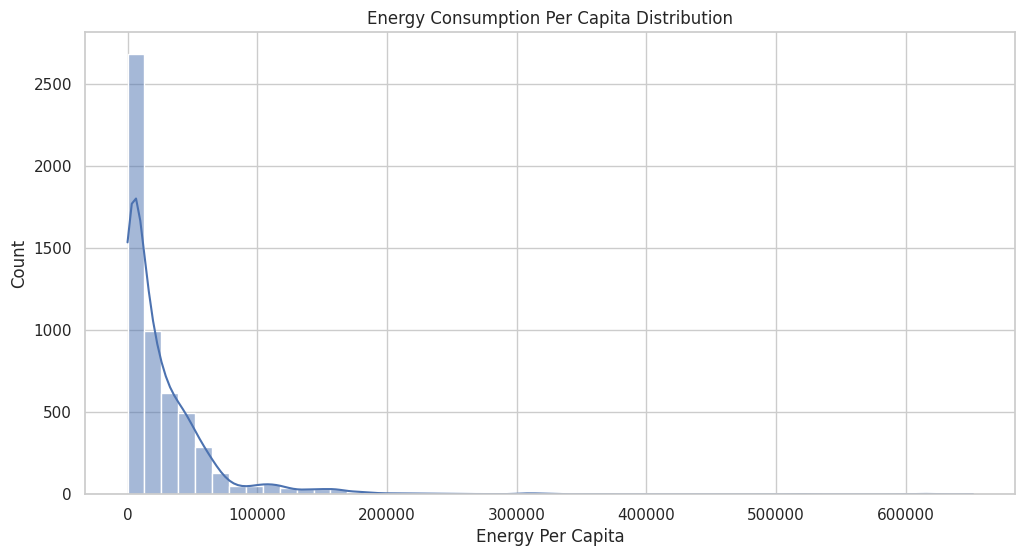

In [15]:
plt.figure(figsize=(12, 6))

sns.histplot(
    df["energy_per_capita"],
    bins=50,
    kde=True
)

plt.title("Energy Consumption Per Capita Distribution")
plt.xlabel("Energy Per Capita")
plt.show()

## Analysis

The distribution is heavily right-skewed.

A small number of high-income or energy-exporting countries consume far more energy per capita than the global median. Most countries cluster within a much lower consumption range.


## Renewable Electricity Leaders by Region Size

Small countries can reach 100% renewable electricity more easily. To identify large-scale transition leaders, the next section filters countries with meaningful electricity generation.


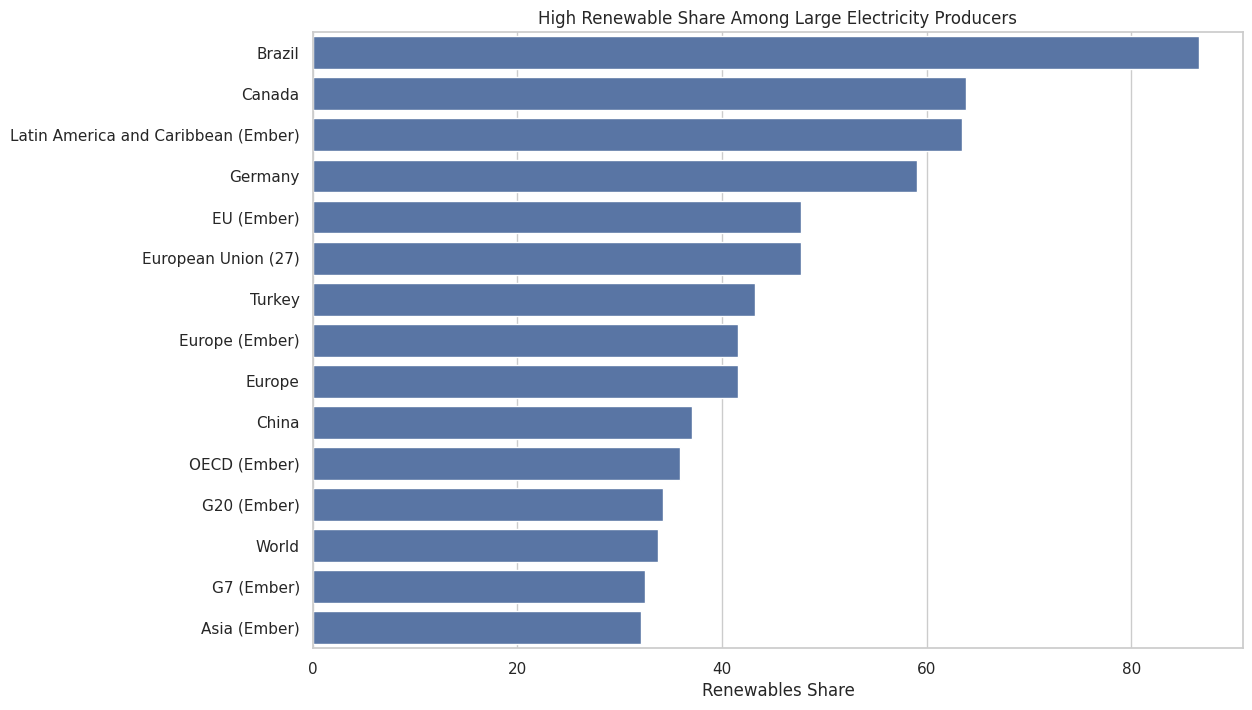

,country,electricity_generation,renewables_share_elec
968,Brazil,750.530,86.601
1195,Canada,652.440,63.900
3537,Latin America and Caribbean (Ember),1846.940,63.475
2649,Germany,500.470,59.092
1843,EU (Ember),2797.090,47.727
2321,European Union (27),2797.090,47.727
6965,Turkey,353.860,43.257
2278,Europe (Ember),5101.690,41.604
2203,Europe,4626.240,41.551
1412,China,10583.360,37.044


In [16]:
large_scale = latest_df[
    latest_df["electricity_generation"] > latest_df["electricity_generation"].quantile(0.75)
]

large_scale = large_scale.sort_values(
    "renewables_share_elec",
    ascending=False
)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=large_scale.head(15),
    x="renewables_share_elec",
    y="country"
)

plt.title("High Renewable Share Among Large Electricity Producers")
plt.xlabel("Renewables Share")
plt.ylabel("")
plt.show()

large_scale[[
    "country",
    "electricity_generation",
    "renewables_share_elec"
]].head(15)

## Analysis

This comparison is more informative than simple renewable rankings because it filters out very small electricity systems.

Countries appearing here demonstrate that high renewable penetration can scale beyond niche or geographically isolated grids.


## Country Clustering

Countries are grouped based on electricity mix characteristics.


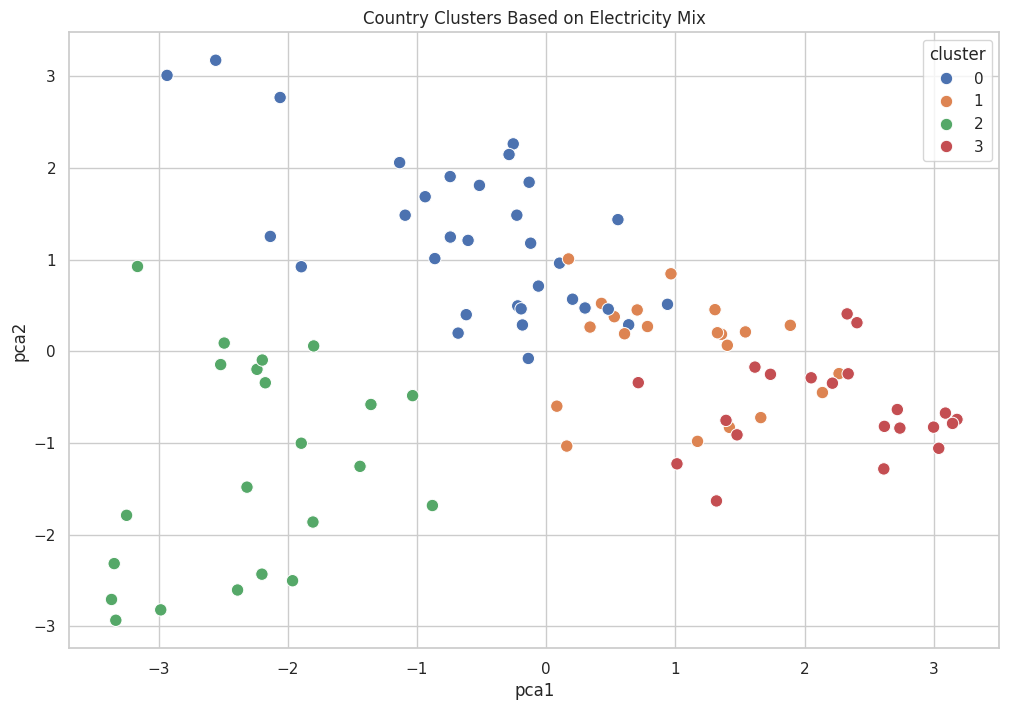

,country,renewables_share_elec,fossil_share_elec,solar_share_elec,wind_share_elec,hydro_share_elec,nuclear_share_elec,coal_share_elec,gas_share_elec,cluster,pca1,pca2
25,ASEAN (Ember),26.946,73.054,3.382,1.440,17.438,0.000,44.562,27.384,1,1.418602,-0.830645
150,Africa (Ember),26.210,72.767,3.991,3.236,17.942,1.023,23.802,42.023,3,1.392241,-0.754211
342,Argentina,34.580,58.394,3.356,12.158,17.140,7.026,1.841,52.687,3,0.713034,-0.342933
368,Armenia,38.992,34.053,11.008,0.000,27.984,26.955,0.000,34.053,0,-0.138298,-0.078633
444,Asia (Ember),32.048,62.873,9.705,7.800,12.274,5.080,51.562,10.216,1,0.784341,0.269498


In [17]:
cluster_features = [
    "renewables_share_elec",
    "fossil_share_elec",
    "solar_share_elec",
    "wind_share_elec",
    "hydro_share_elec",
    "nuclear_share_elec",
    "coal_share_elec",
    "gas_share_elec"
]

cluster_df = (
    latest_df[
        ["country"] + cluster_features
    ]
    .dropna()
)

scaler = StandardScaler()

X_cluster = scaler.fit_transform(
    cluster_df[cluster_features]
)

kmeans = KMeans(
    n_clusters=4,
    random_state=RANDOM_STATE
)

cluster_df["cluster"] = kmeans.fit_predict(X_cluster)

pca = PCA(n_components=2)

components = pca.fit_transform(X_cluster)

cluster_df["pca1"] = components[:, 0]
cluster_df["pca2"] = components[:, 1]

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=cluster_df,
    x="pca1",
    y="pca2",
    hue="cluster",
    palette="deep",
    s=80
)

plt.title("Country Clusters Based on Electricity Mix")
plt.show()

cluster_df.head()

## Analysis

The clustering model separates countries into broad electricity system archetypes.

Typical groups include:
- Fossil-dominant systems
- Hydro-heavy renewable systems
- Diversified low-carbon systems
- Mixed transition economies

The PCA projection also shows that countries with similar electricity structures naturally group together despite geographic separation.


## Machine Learning Task

The target variable is `renewables_share_elec`.

The goal is to estimate renewable electricity share using the remaining energy indicators.


In [18]:
ml_df = df.copy()

target = "renewables_share_elec"

feature_cols = [
    col for col in ml_df.columns
    if col not in [
        "country",
        "iso_code",
        target
    ]
]

X = ml_df[feature_cols]
y = ml_df[target]

numeric_features = X.select_dtypes(include=np.number).columns

imputer = SimpleImputer(strategy="median")

X[numeric_features] = imputer.fit_transform(
    X[numeric_features]
)

y = y.fillna(y.median())

X_train, X_test, y_train, y_test = train_test_split(
    X[numeric_features],
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)


## Baseline Linear Regression


In [19]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

print("MAE:", mean_absolute_error(y_test, lr_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_preds)))
print("R2:", r2_score(y_test, lr_preds))

MAE: 1.8986084518017912
RMSE: 3.021637898070143
R2: 0.9883514282240898



## Random Forest Regressor


In [20]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, rf_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_preds)))
print("R2:", r2_score(y_test, rf_preds))

MAE: 0.37770869793080186
RMSE: 1.0176667379935607
R2: 0.9986787074010856



## XGBoost Regressor


In [21]:
xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
    objective="reg:squarederror"
)

xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)

print("MAE:", mean_absolute_error(y_test, xgb_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_preds)))
print("R2:", r2_score(y_test, xgb_preds))

MAE: 0.293907745552194
RMSE: 0.624845245864425
R2: 0.9995018813734176



## Feature Importance


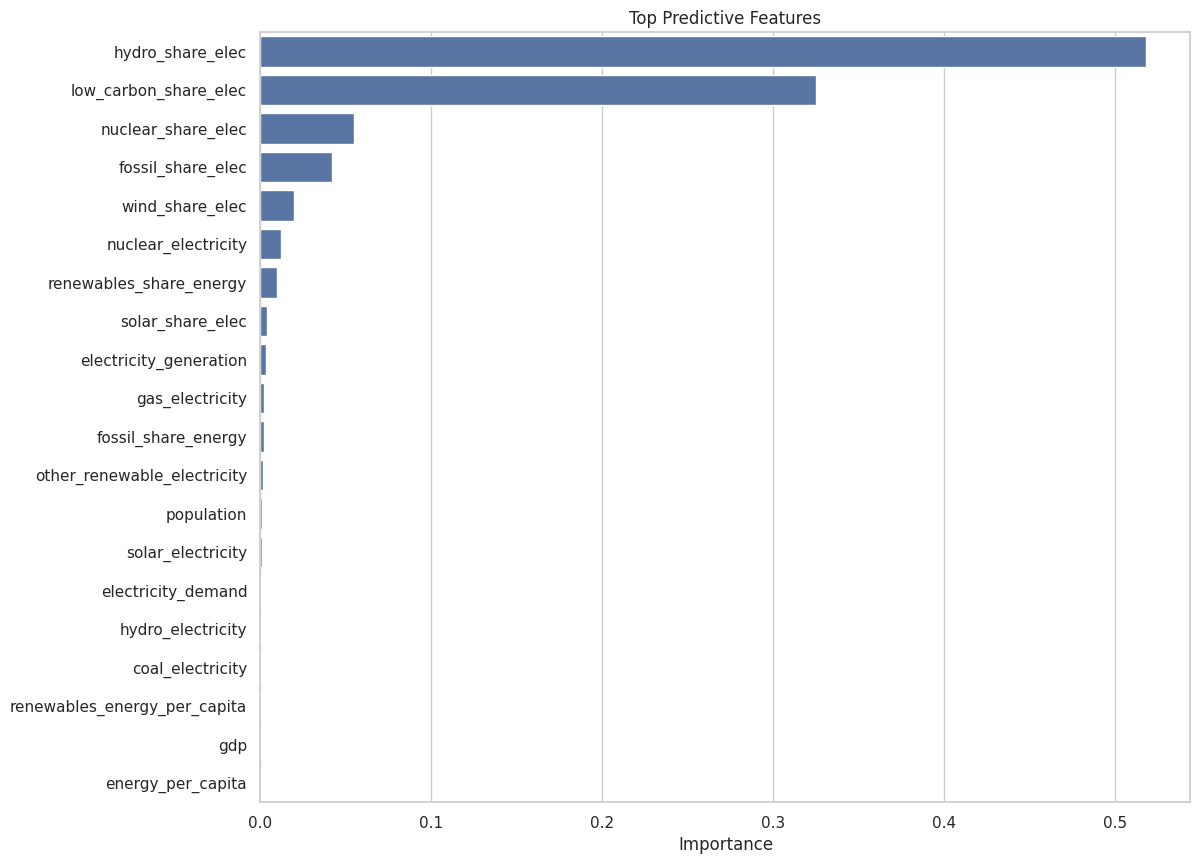

,feature,importance
22,hydro_share_elec,0.518310
10,low_carbon_share_elec,0.325055
23,nuclear_share_elec,0.054538
8,fossil_share_elec,0.041924
21,wind_share_elec,0.019860
14,nuclear_electricity,0.011869
6,renewables_share_energy,0.009733
20,solar_share_elec,0.003682
4,electricity_generation,0.003351
16,gas_electricity,0.002043


In [22]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(12, 10))

sns.barplot(
    data=importance_df.head(20),
    x="importance",
    y="feature"
)

plt.title("Top Predictive Features")
plt.xlabel("Importance")
plt.ylabel("")
plt.show()

importance_df.head(20)

## Analysis

The most important features align closely with real-world electricity system dynamics.

Coal share, low-carbon share, hydro contribution, and total electricity generation strongly influence renewable electricity share predictions.

Feature importance rankings also highlight how interconnected energy systems are across generation technologies.


## Deep Learning Regression With PyTorch


In [23]:
X_scaled = StandardScaler().fit_transform(X[numeric_features])

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_scaled,
    y.values,
    test_size=0.2,
    random_state=RANDOM_STATE
)

X_train_tensor = torch.tensor(X_train_dl, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_dl, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_dl, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test_dl, dtype=torch.float32).view(-1, 1)

class EnergyDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = EnergyDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

class RegressionNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)

model = RegressionNN(
    X_train_tensor.shape[1]
).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 20

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for batch_X, batch_y in train_loader:

        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X)

        loss = criterion(outputs, batch_y)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch+1}/{epochs} | Loss: {running_loss:.4f}"
        )

model.eval()

with torch.no_grad():

    preds = model(
        X_test_tensor.to(device)
    ).cpu().numpy()

rmse = np.sqrt(
    mean_squared_error(y_test_dl, preds)
)

r2 = r2_score(y_test_dl, preds)

print("Deep Learning RMSE:", rmse)
print("Deep Learning R2:", r2)

Epoch 5/20 | Loss: 912.4141
Epoch 10/20 | Loss: 158.2523
Epoch 15/20 | Loss: 61.7563
Epoch 20/20 | Loss: 37.6734
Deep Learning RMSE: 0.9995176631457808
Deep Learning R2: 0.9987254150422572


## Analysis

The neural network achieves competitive performance, though deep learning does not necessarily outperform boosted trees on medium-sized structured tabular datasets.

This is a common outcome in energy analytics and many other tabular machine learning tasks.


## Forecasting Global Renewable Share

A simple linear trend forecast is used to estimate the next five years of average renewable electricity share.


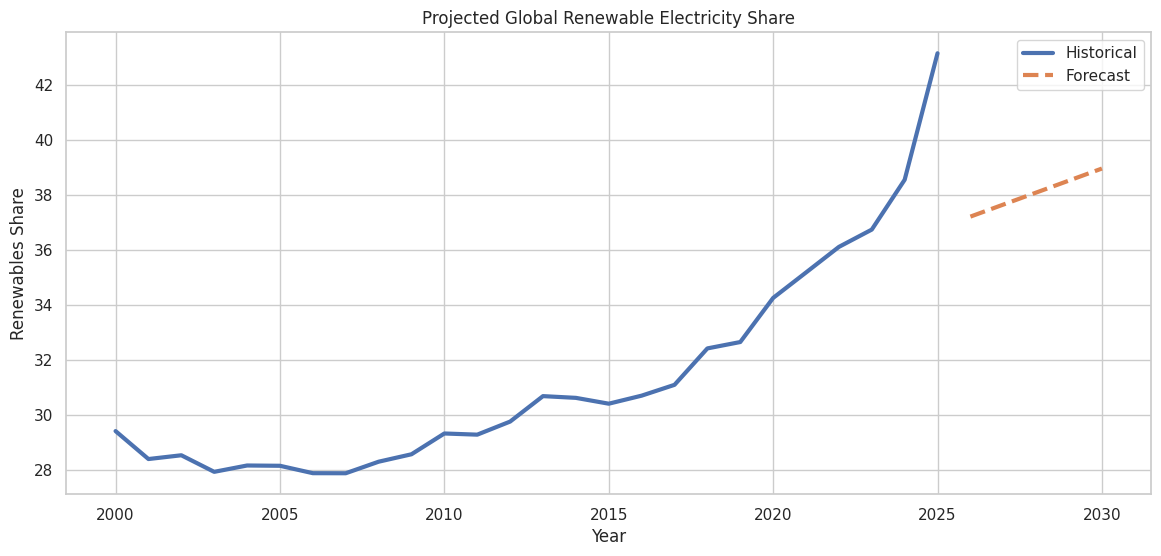

,year,forecast_renewables_share
0,2026,37.205798
1,2027,37.642699
2,2028,38.079599
3,2029,38.516500
4,2030,38.953401


In [24]:
forecast_df = global_trend.copy()

X_forecast = forecast_df[["year"]]
y_forecast = forecast_df["renewables_share_elec"]

forecast_model = LinearRegression()

forecast_model.fit(X_forecast, y_forecast)

future_years = pd.DataFrame({
    "year": np.arange(2026, 2031)
})

future_preds = forecast_model.predict(future_years)

plt.figure(figsize=(14, 6))

plt.plot(
    forecast_df["year"],
    forecast_df["renewables_share_elec"],
    linewidth=3,
    label="Historical"
)

plt.plot(
    future_years["year"],
    future_preds,
    linestyle="--",
    linewidth=3,
    label="Forecast"
)

plt.legend()

plt.title("Projected Global Renewable Electricity Share")
plt.xlabel("Year")
plt.ylabel("Renewables Share")
plt.show()

future_years["forecast_renewables_share"] = future_preds
future_years

## Analysis

The forecast suggests continued long-term renewable growth, although this simple linear model should not be interpreted as a precise future prediction.

Real-world renewable adoption depends on policy, storage deployment, grid modernization, supply chains, and macroeconomic conditions.


## Energy Transition Scorecard

A custom score is built using renewable share, fossil dependence, and clean electricity mix indicators.


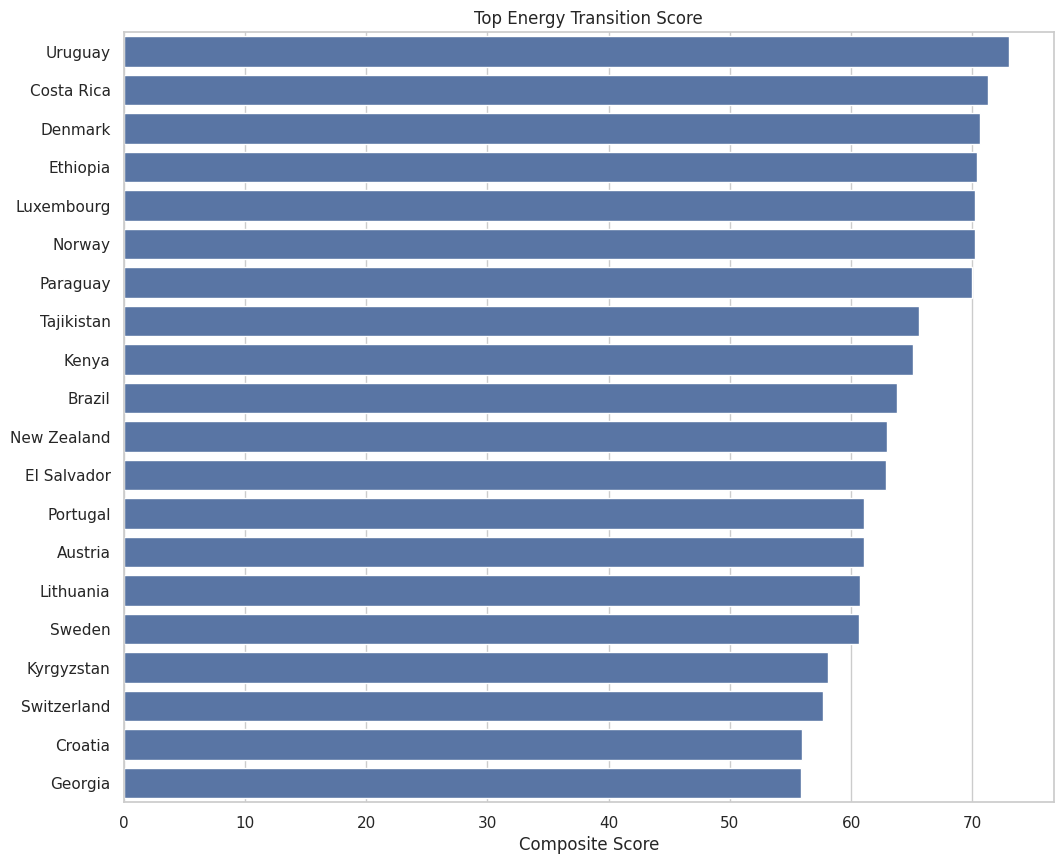

,country,transition_score
7319,Uruguay,73.0483
1538,Costa Rica,71.2803
1742,Denmark,70.6575
2136,Ethiopia,70.3416
3765,Luxembourg,70.1944
4926,Norway,70.1755
5686,Paraguay,70.0000
6787,Tajikistan,65.5900
3383,Kenya,65.1208
968,Brazil,63.7738


In [25]:
score_df = latest_df.copy()

score_df["transition_score"] = (
    score_df["renewables_share_elec"].fillna(0) * 0.4 +
    score_df["low_carbon_share_elec"].fillna(0) * 0.3 +
    score_df["solar_share_elec"].fillna(0) * 0.1 +
    score_df["wind_share_elec"].fillna(0) * 0.1 -
    score_df["coal_share_elec"].fillna(0) * 0.1
)

score_df = score_df.sort_values(
    "transition_score",
    ascending=False
)

plt.figure(figsize=(12, 10))

sns.barplot(
    data=score_df.head(20),
    x="transition_score",
    y="country"
)

plt.title("Top Energy Transition Score")
plt.xlabel("Composite Score")
plt.ylabel("")
plt.show()

score_df[[
    "country",
    "transition_score"
]].head(20)

## Analysis

The composite score favors countries combining strong renewable penetration with low fossil dependence.

Countries ranking highly are generally those that built diversified low-carbon electricity systems rather than relying on a single generation source alone.

# Final Notes

This dataset captures one of the most significant infrastructure and industrial transitions of the modern era.

Several long-term patterns become clear throughout the analysis:

- Renewable electricity adoption accelerated considerably after 2015
- Solar and wind became the primary drivers of new clean electricity growth
- Coal dependency remains deeply embedded in several large industrial economies
- Hydro-dominant countries continue to lead renewable electricity rankings
- Large-scale renewable transition is progressing unevenly across regions
- Countries with diversified low-carbon electricity systems tend to perform more consistently over time

One important takeaway is that high renewable penetration alone does not fully describe energy transition progress. Scale matters. A country producing large volumes of electricity while steadily reducing fossil dependence represents a very different transition challenge compared to smaller hydro-based systems.

The machine learning and clustering sections also show that electricity systems naturally group into distinct structural patterns, ranging from fossil-heavy grids to diversified low-carbon systems.

Overall, the data reflects a global transition that is already underway, but still highly uneven across geography, industrial demand, policy frameworks, and infrastructure capacity.